# 02 — Concentration risk

**Plain English:** *Concentration* asks "are we putting too many eggs in one basket?" We measure how exposure (total gross approval $) spreads across **industries**, **states**, **originating lenders** (the channel) and **borrowers** (single-name / franchise brands).

Two standard measures:
- **Top-N share** — the % of the book held by the largest N segments.
- **HHI (Herfindahl–Hirschman Index)** — the sum of squared segment shares. 0 = perfectly diversified, 1.0 = everything in one segment; higher = more concentrated.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
pd.set_option('display.max_columns', 40, 'display.width', 200)
from src.config import load_config, TABLES_DIR
CFG = load_config()

In [2]:
from src.data_loader import load_clean
from src.base_table import build_base_table
loans = load_clean(config=CFG)
base = build_base_table(loans, config=CFG)
print(f'{len(base):,} funded loans, vintages {int(base.vintage.min())}-{int(base.vintage.max())}')

[2026-06-25 13:10:30] [INFO    ] [data_loader] Loading 2 SBA input file(s): ['foia-7a-fy2000-fy2009-asof-260331.csv', 'foia-7a-fy2010-fy2019-asof-260331.csv']


[2026-06-25 13:10:33] [INFO    ] [data_loader]   foia-7a-fy2000-fy2009-asof-260331.csv -> 690333 rows


[2026-06-25 13:10:36] [INFO    ] [data_loader]   foia-7a-fy2010-fy2019-asof-260331.csv -> 545751 rows


[2026-06-25 13:10:36] [INFO    ] [data_loader] Combined raw frame: 1236084 rows


[2026-06-25 13:10:39] [INFO    ] [data_loader] Dropped 149065 never-funded loans (['CANCLD', 'COMMIT']); 1087019 funded loans remain


[2026-06-25 13:10:41] [INFO    ] [base_table] Base table built: 1087019 loans, 20 vintages (2000-2019), 132662 defaults, 9805 problem exposures


1,087,019 funded loans, vintages 2000-2019


In [3]:
from src import concentration as conc
from src.charts import plot_concentration_bar
hhi = conc.hhi_summary(base)
hhi.to_csv(TABLES_DIR / '02_concentration_hhi_summary.csv', index=False)
ind = conc.concentration_by(base, 'industry')
st = conc.concentration_by(base, 'state')
ld = conc.concentration_by(base, 'lender')
bo = conc.concentration_by(base, 'borrower')
ind.to_csv(TABLES_DIR / '02_concentration_industry.csv', index=False)
st.to_csv(TABLES_DIR / '02_concentration_state.csv', index=False)
ld.to_csv(TABLES_DIR / '02_concentration_lender.csv', index=False)
bo.to_csv(TABLES_DIR / '02_concentration_borrower.csv', index=False)

[2026-06-25 13:10:41] [INFO    ] [concentration] Concentration industry: HHI=0.1004 (Moderate), 21 segments


[2026-06-25 13:10:41] [INFO    ] [concentration] Concentration state: HHI=0.0577 (Low), 60 segments


[2026-06-25 13:10:41] [INFO    ] [concentration] Concentration lender: HHI=0.0144 (Low), 4222 segments


[2026-06-25 13:10:43] [INFO    ] [concentration] Concentration borrower: HHI=0.0000 (Low), 910400 segments


### Result: HHI + top-N exposure share by dimension

In [4]:
hhi

,dimension,segments,hhi,concentration_level,top10_exposure_share
0,industry,21,0.100406,Moderate,0.8748
1,state,60,0.057744,Low,0.5713
2,lender,4222,0.014408,Low,0.3025
3,borrower,910400,0.000007,Low,0.0026


#### Top industries by exposure (with each segment's charge-off rate)

In [5]:
ind

,industry,loan_count,exposure,defaults,chargeoff_amount,exposure_share,count_share,chargeoff_rate_count,chargeoff_rate_dollar
0,Accommodation & Food Services,133403,5.101697e+10,16373,3.659654e+09,0.1773,0.1227,0.1227,0.0717
1,Retail Trade,174624,4.418474e+10,24874,3.639054e+09,0.1535,0.1606,0.1424,0.0824
2,Manufacturing,87762,3.030025e+10,9328,1.945051e+09,0.1053,0.0807,0.1063,0.0642
3,Health Care & Social Assistance,87527,2.959416e+10,5924,1.248399e+09,0.1028,0.0805,0.0677,0.0422
4,Other Services (except Public Admin),104527,2.427371e+10,12883,1.791361e+09,0.0843,0.0962,0.1233,0.0738
5,"Professional, Scientific & Technical Services",104993,2.038662e+10,11936,1.209750e+09,0.0708,0.0966,0.1137,0.0593
6,Wholesale Trade,60185,1.856048e+10,8907,1.192667e+09,0.0645,0.0554,0.1480,0.0643
7,Construction,104884,1.707175e+10,14342,1.570478e+09,0.0593,0.0965,0.1367,0.0920
8,"Arts, Entertainment & Recreation",26375,8.271858e+09,3307,6.360027e+08,0.0287,0.0243,0.1254,0.0769
9,Administrative & Waste Management Services,53337,8.128158e+09,6916,6.538930e+08,0.0282,0.0491,0.1297,0.0804


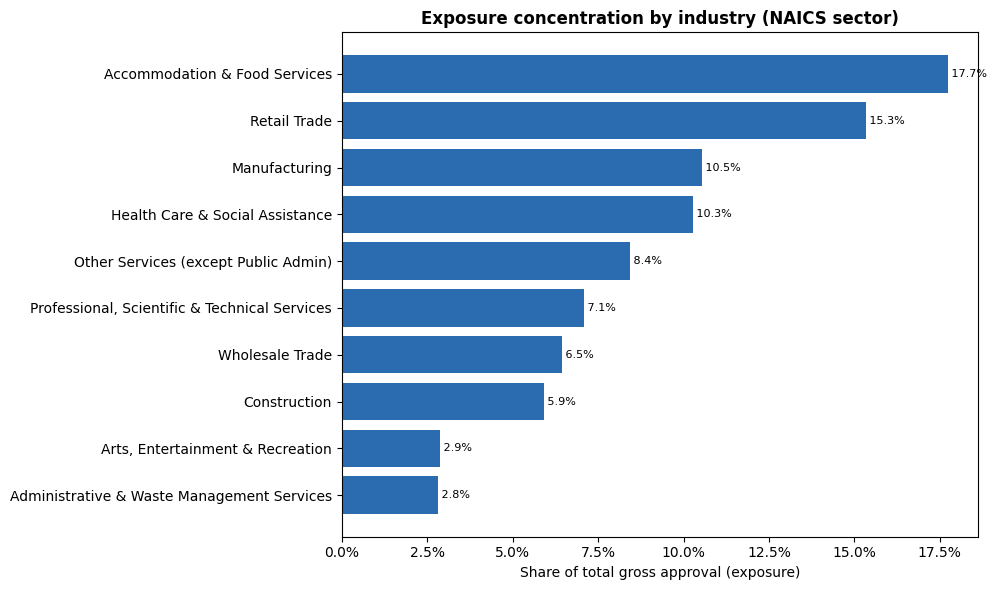

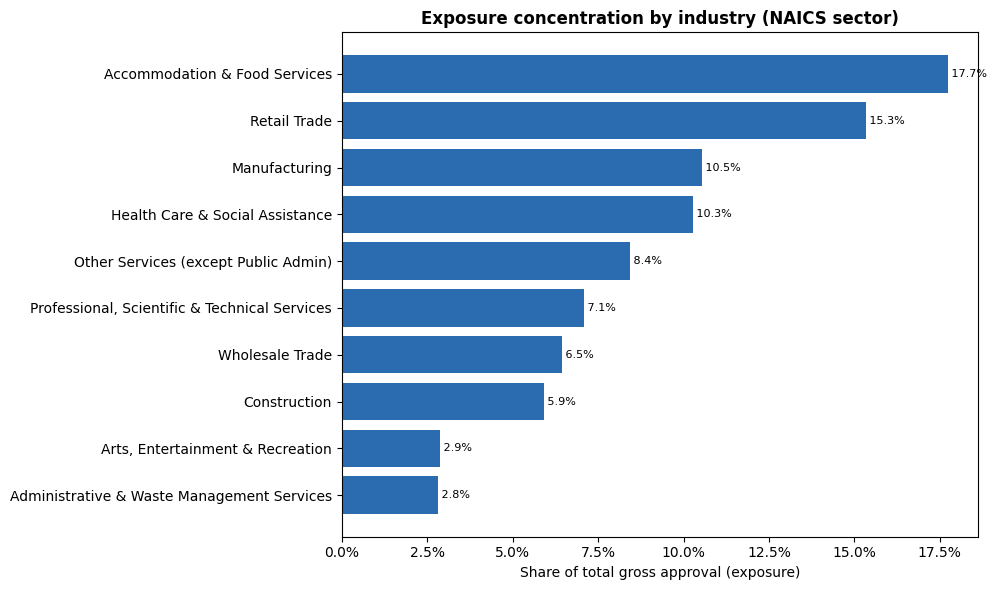

In [6]:
plot_concentration_bar(ind, 'industry', 'Exposure concentration by industry (NAICS sector)')

**Read-out:** the book is **moderately** concentrated by industry (HHI ≈ 0.10) but **well diversified** across states, the 4,000+ originating lenders and >900k borrowers (single-name share is immaterial — the largest names are franchise brands, a correlated-cluster to watch). Industry is the dimension worth watching.